# **DATASCI 266 Final Project**

**Comparing Traditional, Multilingual, and Korean-Specific Models for Korean Sentiment Classification using KOTE**

# **0. Environment Setup**



In [1]:
!pip -q install transformers datasets accelerate sentencepiece sacremoses scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from datasets import load_dataset, Dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoModelForSeq2SeqLM


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 22.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. Load Dataset**

This section loads the KOTE dataset from Hugging Face and converts the train, validation, and test splits to pandas DataFrames for inspection and preprocessing.

In [ ]:
dataset = load_dataset(
    "searle-j/kote",
    revision="refs/convert/parquet"
)

train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

df_train = train_ds.to_pandas()
df_val = val_ds.to_pandas()
df_test = test_ds.to_pandas()

print(dataset)
print(df_train.head())

dichotomized/train/0000.parquet:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/607k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/599k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'text', 'labels'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['ID', 'text', 'labels'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['ID', 'text', 'labels'],
        num_rows: 5000
    })
})
      ID                                               text  \
0  39087              내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.   
1  30893  정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...   
2  45278  새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...   
3  16398       미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ   
4  13653                        네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ   

                                             labels  
0                           [2, 13, 15, 16, 29, 39]  
1             [0, 5, 7, 10, 19, 22, 29, 35, 36, 38]  
2                                         [1, 2, 7]  
3                       [9, 15, 20, 23, 26, 28, 29]  
4  [1, 2, 8, 9, 11, 13, 15, 16, 28, 29, 32, 

In [ ]:
df_train.to_csv("df_train_processed.csv", index=False)
df_val.to_csv("df_val_processed.csv", index=False)
df_test.to_csv("df_test_processed.csv", index=False)

In [ ]:
df_train.to_csv("/content/drive/MyDrive/df_train_processed.csv", index=False)
df_val.to_csv("/content/drive/MyDrive/df_val_processed.csv", index=False)
df_test.to_csv("/content/drive/MyDrive/df_test_processed.csv", index=False)

# **2. Inspect Label Metadata**

The original KOTE labels are represented as integer IDs. This section recovers the label names from the Hugging Face metadata.

In [ ]:
label_names = train_ds.features["labels"].feature.names
id_to_label = {i: name for i, name in enumerate(label_names)}

print(train_ds.features["labels"])
print(id_to_label)

List(ClassLabel(names=['불평/불만', '환영/호의', '감동/감탄', '지긋지긋', '고마움', '슬픔', '화남/분노', '존경', '기대감', '우쭐댐/무시함', '안타까움/실망', '비장함', '의심/불신', '뿌듯함', '편안/쾌적', '신기함/관심', '아껴주는', '부끄러움', '공포/무서움', '절망', '한심함', '역겨움/징그러움', '짜증', '어이없음', '없음', '패배/자기혐오', '귀찮음', '힘듦/지침', '즐거움/신남', '깨달음', '죄책감', '증오/혐오', '흐뭇함(귀여움/예쁨)', '당황/난처', '경악', '부담/안_내킴', '서러움', '재미없음', '불쌍함/연민', '놀람', '행복', '불안/걱정', '기쁨', '안심/신뢰']))
{0: '불평/불만', 1: '환영/호의', 2: '감동/감탄', 3: '지긋지긋', 4: '고마움', 5: '슬픔', 6: '화남/분노', 7: '존경', 8: '기대감', 9: '우쭐댐/무시함', 10: '안타까움/실망', 11: '비장함', 12: '의심/불신', 13: '뿌듯함', 14: '편안/쾌적', 15: '신기함/관심', 16: '아껴주는', 17: '부끄러움', 18: '공포/무서움', 19: '절망', 20: '한심함', 21: '역겨움/징그러움', 22: '짜증', 23: '어이없음', 24: '없음', 25: '패배/자기혐오', 26: '귀찮음', 27: '힘듦/지침', 28: '즐거움/신남', 29: '깨달음', 30: '죄책감', 31: '증오/혐오', 32: '흐뭇함(귀여움/예쁨)', 33: '당황/난처', 34: '경악', 35: '부담/안_내킴', 36: '서러움', 37: '재미없음', 38: '불쌍함/연민', 39: '놀람', 40: '행복', 41: '불안/걱정', 42: '기쁨', 43: '안심/신뢰'}


# **3. Consolidate 43 Emotion Labels into 3 Sentiment Classes**

The original KOTE dataset contains 43 fine-grained emotion labels. Following Appendix A of Jeon et al. (2024), the labels are consolidated into three broader categories: negative, positive, and neutral.

In [ ]:
label_to_sentiment = {
    # Negative
    '불평/불만': 'negative',
    '지긋지긋': 'negative',
    '슬픔': 'negative',
    '화남/분노': 'negative',
    '안타까움/실망': 'negative',
    '의심/불신': 'negative',
    '부끄러움': 'negative',
    '공포/무서움': 'negative',
    '절망': 'negative',
    '한심함': 'negative',
    '역겨움/징그러움': 'negative',
    '짜증': 'negative',
    '어이없음': 'negative',
    '패배/자기혐오': 'negative',
    '귀찮음': 'negative',
    '힘듦/지침': 'negative',
    '죄책감': 'negative',
    '증오/혐오': 'negative',
    '당황/난처': 'negative',
    '경악': 'negative',
    '부담/안_내킴': 'negative',
    '서러움': 'negative',
    '재미없음': 'negative',
    '불쌍함/연민': 'negative',
    '불안/걱정': 'negative',

    # Positive
    '환영/호의': 'positive',
    '감동/감탄': 'positive',
    '고마움': 'positive',
    '존경': 'positive',
    '기대감': 'positive',
    '뿌듯함': 'positive',
    '편안/쾌적': 'positive',
    '신기함/관심': 'positive',
    '아껴주는': 'positive',
    '즐거움/신남': 'positive',
    '흐뭇함(귀여움/예쁨)': 'positive',
    '행복': 'positive',
    '기쁨': 'positive',
    '안심/신뢰': 'positive',

    # Neutral
    '우쭐댐/무시함': 'neutral',
    '비장함': 'neutral',
    '없음': 'neutral',
    '깨달음': 'neutral',
    '놀람': 'neutral',
}

In [ ]:
score_map = {"negative": -1, "neutral": 0, "positive": 1}

def collapse_labels_score(label_ids):
    sentiments = [label_to_sentiment[id_to_label[i]] for i in label_ids]
    score = sum(score_map[s] for s in sentiments)
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

In [ ]:
df_train["sentiment"] = df_train["labels"].apply(collapse_labels_score)
df_val["sentiment"] = df_val["labels"].apply(collapse_labels_score)
df_test["sentiment"] = df_test["labels"].apply(collapse_labels_score)

In [ ]:
sentiment_to_id = {"negative": 0, "positive": 1, "neutral": 2}

df_train["y"] = df_train["sentiment"].map(sentiment_to_id)
df_val["y"] = df_val["sentiment"].map(sentiment_to_id)
df_test["y"] = df_test["sentiment"].map(sentiment_to_id)

# **4. Exploratory Data Analysis (EDA)**


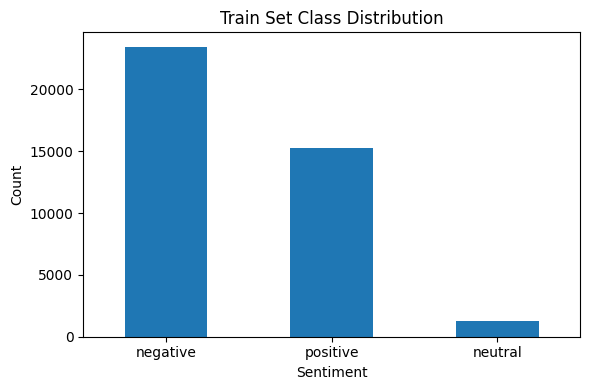

In [ ]:
df_train["sentiment"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Train Set Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

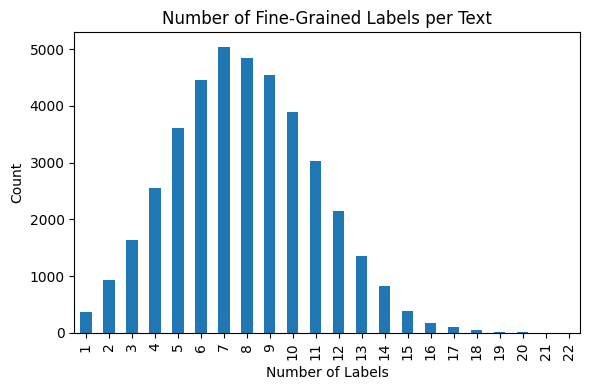

In [ ]:
df_train["num_labels"] = df_train["labels"].apply(len)

df_train["num_labels"].value_counts().sort_index().plot(kind="bar", figsize=(6,4))
plt.title("Number of Fine-Grained Labels per Text")
plt.xlabel("Number of Labels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

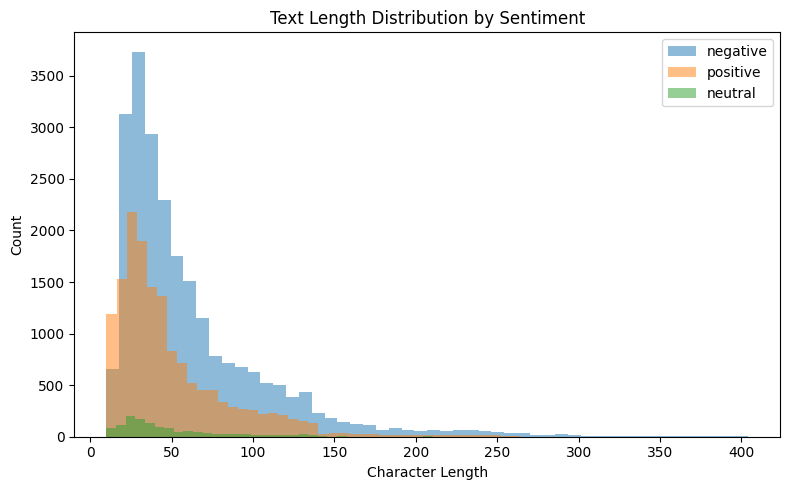

In [ ]:
df_train["text_len"] = df_train["text"].apply(len)

plt.figure(figsize=(8,5))
for sentiment in ["negative", "positive", "neutral"]:
    subset = df_train[df_train["sentiment"] == sentiment]["text_len"]
    plt.hist(subset, bins=50, alpha=0.5, label=sentiment)

plt.title("Text Length Distribution by Sentiment")
plt.xlabel("Character Length")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df_train["num_labels"].describe())
print(df_train.groupby("sentiment")["text_len"].describe()[["mean", "std", "min", "max"]])



count    40000.000000
mean         7.911475
std          3.098085
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         22.000000
Name: num_labels, dtype: float64
                mean        std   min    max
sentiment                                   
negative   62.008786  48.726013  10.0  404.0
neutral    51.161585  38.525371  10.0  305.0
positive   50.329287  37.679431  10.0  320.0


In [ ]:
print(df_train["num_labels"].describe())
print(df_train.groupby("sentiment")["text_len"].describe()[["mean", "std", "min", "max"]])

count    40000.000000
mean         7.911475
std          3.098085
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         22.000000
Name: num_labels, dtype: float64
                mean        std   min    max
sentiment                                   
negative   62.008786  48.726013  10.0  404.0
neutral    51.161585  38.525371  10.0  305.0
positive   50.329287  37.679431  10.0  320.0


# **5. TF-IDF + Logistic Regression Baseline**

A traditional bag-of-words baseline is built using TF-IDF features and multiclass logistic regression.

In [ ]:
X_train = df_train["text"]
y_train = df_train["y"]

X_val = df_val["text"]
y_val = df_val["y"]

X_test = df_test["text"]
y_test = df_test["y"]

In [ ]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

In [ ]:
baseline.fit(X_train, y_train)

val_pred = baseline.predict(X_val)
test_pred = baseline.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation Macro-F1:", f1_score(y_val, val_pred, average="macro"))

print("\nTest Accuracy:", accuracy_score(y_test, test_pred))
print("Test Macro-F1:", f1_score(y_test, test_pred, average="macro"))

Validation Accuracy: 0.7042
Validation Macro-F1: 0.5190351295110717

Test Accuracy: 0.6904
Test Macro-F1: 0.4988920302721864


In [ ]:
label_names_3 = ["negative", "positive", "neutral"]

print(classification_report(y_test, test_pred, target_names=label_names_3))
print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

    negative       0.79      0.76      0.77      2978
    positive       0.69      0.63      0.66      1865
     neutral       0.04      0.12      0.06       157

    accuracy                           0.69      5000
   macro avg       0.51      0.50      0.50      5000
weighted avg       0.73      0.69      0.71      5000

[[2253  473  252]
 [ 513 1180  172]
 [  74   64   19]]


# **6. Prepare Hugging Face Datasets for Transformer Models**



In [ ]:
train_hf = Dataset.from_pandas(df_train[["text", "y"]].reset_index(drop=True))
val_hf = Dataset.from_pandas(df_val[["text", "y"]].reset_index(drop=True))
test_hf = Dataset.from_pandas(df_test[["text", "y"]].reset_index(drop=True))

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# **7. KLUE-RoBERTa**

This section fine-tunes a Korean-specific pretrained transformer model on the consolidated 3-class sentiment task.

In [ ]:
model_name = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tok = train_hf.map(tokenize_function, batched=True)
val_tok = val_hf.map(tokenize_function, batched=True)
test_tok = test_hf.map(tokenize_function, batched=True)

train_tok = train_tok.rename_column("y", "labels")
val_tok = val_tok.rename_column("y", "labels")
test_tok = test_tok.rename_column("y", "labels")

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./klue_roberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.430524,0.410822,0.852800,0.569721
2,0.295720,0.447586,0.861400,0.592391
3,0.205765,0.547262,0.864200,0.617473


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7500, training_loss=0.3106693115234375, metrics={'train_runtime': 2874.2777, 'train_samples_per_second': 41.75, 'train_steps_per_second': 2.609, 'total_flos': 7893402531840000.0, 'train_loss': 0.3106693115234375, 'epoch': 3.0})

In [ ]:
val_results = trainer.evaluate(val_tok)
test_results = trainer.evaluate(test_tok)

print("Validation Results:", val_results)
print("Test Results:", test_results)

Validation Results: {'eval_loss': 0.5472621321678162, 'eval_accuracy': 0.8642, 'eval_macro_f1': 0.617473155213817, 'eval_runtime': 38.2063, 'eval_samples_per_second': 130.868, 'eval_steps_per_second': 8.192, 'epoch': 3.0}
Test Results: {'eval_loss': 0.5196225643157959, 'eval_accuracy': 0.8682, 'eval_macro_f1': 0.6421069115533848, 'eval_runtime': 36.1214, 'eval_samples_per_second': 138.422, 'eval_steps_per_second': 8.665, 'epoch': 3.0}


In [ ]:
klue_test_preds_output = trainer.predict(test_tok)
klue_test_preds = np.argmax(klue_test_preds_output.predictions, axis=1)
klue_test_labels = klue_test_preds_output.label_ids

print(classification_report(klue_test_labels, klue_test_preds, target_names=label_names_3))
print(confusion_matrix(klue_test_labels, klue_test_preds))

              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      2978
    positive       0.84      0.87      0.85      1865
     neutral       0.22      0.13      0.17       157

    accuracy                           0.87      5000
   macro avg       0.65      0.64      0.64      5000
weighted avg       0.86      0.87      0.86      5000

[[2695  242   41]
 [ 205 1625   35]
 [  57   79   21]]


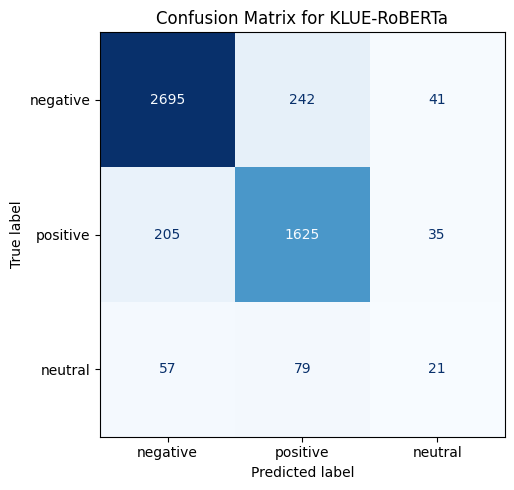

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([
    [2695, 242, 41],
    [205, 1625, 35],
    [57, 79, 21]
])

label_names_3 = ["negative", "positive", "neutral"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names_3)
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)

plt.title("Confusion Matrix for KLUE-RoBERTa")
plt.tight_layout()
plt.show()

In [ ]:
np.save("klue_test_preds.npy", klue_test_preds)
np.save("klue_test_labels.npy", klue_test_labels)



In [ ]:
np.save("/content/drive/MyDrive/klue_test_preds.npy", klue_test_preds)
np.save("/content/drive/MyDrive/klue_test_labels.npy", klue_test_labels)

['.config', 'xlmr_results', 'mbert_results', 'df_test_processed.csv', 'df_train_processed.csv', 'df_val_processed.csv', 'drive', 'sample_data']
['Colab Notebooks', 'Getting started.pdf', 'SchoolWork', 'Screen Shot 2016-10-04 at 9.03.25 AM.png', 'P1030488.JPG', 'P1030490.JPG', 'P1030487.JPG', 'P1030484.JPG', 'P1030483.JPG', 'P1030489.JPG', 'P1030486.JPG', 'WIN_20161130_17_52_46_Pro.mp4', '서비스마케팅 묶음.ppt', '[Donald_Voet,_Judith_G._Voet]_Biochemistry,_4th_Ed(BookZZ.org).pdf', 'Organic Chemistry By Clayden, Greeves, Warren and Wothers.pdf', 'PFSA_Gas_Permeation_Project_Description.docx', 'Confirmation Email.gdoc', 'Waitlist Email.gdoc', 'Covert Timing Channels.gdoc', 'HW5.pdf', 'rubric.JPG', 'rubric2.JPG', 'HW3.pdf', '154Lab', 'Chart1.crtx', 'Intro to Chemical Engineering Thermodynamic.pdf', '문상객.gsheet', 'IMG_1760.JPG', 'IMG_1759.JPG', 'Untitled spreadsheet.gsheet', 'CBE160', 'Process Control Modeling, Design and Simulation (1).gdoc', 'Process Control Modeling, Design and 

# **8. Multilingual BERT (mBERT)**

This section fine-tunes multilingual BERT on the same task to compare multilingual pretraining with Korean-specific pretraining.

In [ ]:
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_tok = train_hf.map(tokenize_function, batched=True)
val_tok = val_hf.map(tokenize_function, batched=True)
test_tok = test_hf.map(tokenize_function, batched=True)

train_tok = train_tok.rename_column("y", "labels")
val_tok = val_tok.rename_column("y", "labels")
test_tok = test_tok.rename_column("y", "labels")

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./mbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.564002,0.532734,0.802600,0.533717
2,0.442814,0.518229,0.805200,0.539492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.564002,0.532734,0.802600,0.533717
2,0.442814,0.518229,0.805200,0.539492
3,0.347303,0.544853,0.810200,0.546527


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7500, training_loss=0.45137298990885416, metrics={'train_runtime': 2839.6349, 'train_samples_per_second': 42.259, 'train_steps_per_second': 2.641, 'total_flos': 7893402531840000.0, 'train_loss': 0.45137298990885416, 'epoch': 3.0})

In [ ]:
val_results = trainer.evaluate(val_tok)
test_results = trainer.evaluate(test_tok)

print("Validation Results:", val_results)
print("Test Results:", test_results)

Validation Results: {'eval_loss': 0.5448525547981262, 'eval_accuracy': 0.8102, 'eval_macro_f1': 0.5465269829884896, 'eval_runtime': 35.9531, 'eval_samples_per_second': 139.07, 'eval_steps_per_second': 8.706, 'epoch': 3.0}
Test Results: {'eval_loss': 0.5325157046318054, 'eval_accuracy': 0.821, 'eval_macro_f1': 0.5503547515236326, 'eval_runtime': 35.3125, 'eval_samples_per_second': 141.593, 'eval_steps_per_second': 8.864, 'epoch': 3.0}


In [ ]:
mbert_test_preds_output = trainer.predict(test_tok)
mbert_test_preds = np.argmax(mbert_test_preds_output.predictions, axis=1)
mbert_test_labels = mbert_test_preds_output.label_ids

label_names_3 = ["negative", "positive", "neutral"]

print(classification_report(mbert_test_labels, mbert_test_preds, target_names=label_names_3))
print(confusion_matrix(mbert_test_labels, mbert_test_preds))

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87      2978
    positive       0.77      0.81      0.79      1865
     neutral       0.00      0.00      0.00       157

    accuracy                           0.82      5000
   macro avg       0.54      0.56      0.55      5000
weighted avg       0.80      0.82      0.81      5000

[[2600  377    1]
 [ 358 1505    2]
 [  73   84    0]]


# **9. XLM-RoBERTa**

This section fine-tunes XLM-RoBERTa as a stronger multilingual baseline.

In [ ]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_tok = train_hf.map(tokenize_function, batched=True)
val_tok = val_hf.map(tokenize_function, batched=True)
test_tok = test_hf.map(tokenize_function, batched=True)

train_tok = train_tok.rename_column("y", "labels")
val_tok = val_tok.rename_column("y", "labels")
test_tok = test_tok.rename_column("y", "labels")

train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./xlmr_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.510774,0.483751,0.841200,0.560670
2,0.390169,0.414599,0.852600,0.572236
3,0.315383,0.458165,0.853000,0.572932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7500, training_loss=0.4054421223958333, metrics={'train_runtime': 3120.0574, 'train_samples_per_second': 38.461, 'train_steps_per_second': 2.404, 'total_flos': 7893402531840000.0, 'train_loss': 0.4054421223958333, 'epoch': 3.0})

In [ ]:
val_results = trainer.evaluate(val_tok)
test_results = trainer.evaluate(test_tok)

print("Validation Results:", val_results)
print("Test Results:", test_results)

Validation Results: {'eval_loss': 0.4581652283668518, 'eval_accuracy': 0.853, 'eval_macro_f1': 0.5729316807660609, 'eval_runtime': 33.4344, 'eval_samples_per_second': 149.546, 'eval_steps_per_second': 9.362, 'epoch': 3.0}
Test Results: {'eval_loss': 0.4670892655849457, 'eval_accuracy': 0.8498, 'eval_macro_f1': 0.5711163560154343, 'eval_runtime': 33.8906, 'eval_samples_per_second': 147.534, 'eval_steps_per_second': 9.236, 'epoch': 3.0}


In [ ]:
xlmr_test_preds_output = trainer.predict(test_tok)
xlmr_test_preds = np.argmax(xlmr_test_preds_output.predictions, axis=1)
xlmr_test_labels = xlmr_test_preds_output.label_ids

print(classification_report(xlmr_test_labels, xlmr_test_preds, target_names=label_names_3))
print(confusion_matrix(xlmr_test_labels, xlmr_test_preds))

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      2978
    positive       0.79      0.86      0.82      1865
     neutral       0.00      0.00      0.00       157

    accuracy                           0.85      5000
   macro avg       0.56      0.58      0.57      5000
weighted avg       0.83      0.85      0.84      5000

[[2643  335    0]
 [ 259 1606    0]
 [  68   89    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
np.save("/content/drive/MyDrive/mbert_test_preds.npy", mbert_test_preds)
np.save("/content/drive/MyDrive/mbert_test_labels.npy", mbert_test_labels)
np.save("/content/drive/MyDrive/xlmr_test_preds.npy", xlmr_test_preds)
np.save("/content/drive/MyDrive/xlmr_test_labels.npy", xlmr_test_labels)

df_train.to_csv("/content/drive/MyDrive/df_train_processed.csv", index=False)
df_val.to_csv("/content/drive/MyDrive/df_val_processed.csv", index=False)
df_test.to_csv("/content/drive/MyDrive/df_test_processed.csv", index=False)

In [ ]:
klue_test_preds = np.load('/content/drive/MyDrive/klue_test_preds.npy')
klue_test_labels = np.load('/content/drive/MyDrive/klue_test_labels.npy')

mbert_test_preds = np.load('/content/drive/MyDrive/mbert_test_preds.npy')
mbert_test_labels = np.load('/content/drive/MyDrive/mbert_test_labels.npy')

xlmr_test_preds = np.load('/content/drive/MyDrive/xlmr_test_preds.npy')
xlmr_test_labels = np.load('/content/drive/MyDrive/xlmr_test_labels.npy')

print(klue_test_preds[:10])
print(klue_test_labels[:10])

[1 0 1 0 0 0 1 1 0 0]
[1 0 1 0 0 0 1 1 0 0]


# **10. Neutral-Class Error Analysis (Using KLUE-RoBERTa)**

This section examines why the neutral class remains difficult even for the strongest model, KLUE-RoBERTa.

In [ ]:
df_test_analysis = df_test.copy().reset_index(drop=True)
df_test_analysis["pred"] = klue_test_preds
df_test_analysis["true_label"] = klue_test_labels

id_to_sentiment = {0: "negative", 1: "positive", 2: "neutral"}

df_test_analysis["true_sentiment"] = df_test_analysis["true_label"].map(id_to_sentiment)
df_test_analysis["pred_sentiment"] = df_test_analysis["pred"].map(id_to_sentiment)

In [ ]:
neutral_true = df_test_analysis[df_test_analysis["true_sentiment"] == "neutral"].copy()

print("Number of true neutral examples:", len(neutral_true))
print(neutral_true["pred_sentiment"].value_counts())

Number of true neutral examples: 157
pred_sentiment
positive    79
negative    57
neutral     21
Name: count, dtype: int64


In [ ]:
def label_ids_to_names(label_ids):
    return [id_to_label[i] for i in label_ids]

neutral_true["label_names"] = neutral_true["labels"].apply(label_ids_to_names)

In [ ]:
neutral_as_negative = neutral_true[neutral_true["pred_sentiment"] == "negative"]
neutral_as_positive = neutral_true[neutral_true["pred_sentiment"] == "positive"]

In [ ]:
for i, row in neutral_as_positive.head(10).iterrows():
    print("TEXT:", row["text"])
    print("LABEL NAMES:", row["label_names"])
    print()

TEXT: 추장관님 적극지지합니다. . 처갓집  검사가 대한민국을 더 이상 흔들지 못하게 해주세요!!!
LABEL NAMES: ['환영/호의', '지긋지긋', '화남/분노', '존경', '기대감', '비장함', '의심/불신', '짜증', '안심/신뢰']

TEXT: 저것의 이름은 카라멜 수제 가죽 케이스라고 합니다.
LABEL NAMES: ['우쭐댐/무시함', '없음', '깨달음', '놀람']

TEXT: 존나 괄호치니까 하이라이트효과 ㅋㅋㅋㅋㅋㅋ
LABEL NAMES: ['감동/감탄', '어이없음', '즐거움/신남', '깨달음', '당황/난처']

TEXT: 오늘 같은 날은 푹 쉬어야 되어요!!
LABEL NAMES: ['환영/호의', '기대감', '비장함', '신기함/관심', '아껴주는', '짜증', '어이없음', '힘듦/지침', '서러움']

TEXT: 요즘도마트에서 팔까요찰떡아이스 나가본지가하도오래되서
LABEL NAMES: ['기대감', '의심/불신', '신기함/관심', '불안/걱정']

TEXT: 알못인데 스타인웨이? 가 콩쿨에서 우승 많이하는 피아노란것만 앎..
LABEL NAMES: ['신기함/관심', '없음', '깨달음', '재미없음']

TEXT: 좋은 현상임부디 이준석을 기점으로 기존 정치, 국회의원들 사고 방식이 달라졌으면 좋겠음북유럽 국회가면 무보수로 국회의원하는 사람들이 자전거로 국회에 일보러가는사람들을 위한 국회의사당 옆에 자전거 주차대가 있음본받아서 우리나라 국회의원들도 이런 사람이 많이 나오길 바람
LABEL NAMES: ['불평/불만', '감동/감탄', '기대감', '안타까움/실망', '신기함/관심', '부끄러움', '깨달음']

TEXT: 생각보다 괜찮앗어요 ㅎㅎ 부드러운걸 생각햇는데ㅠㅠ 딱딱하네욜
LABEL NAMES: ['불평/불만', '기대감', '안타까움/실망', '편안/쾌적', '당황/난처', '안심/신뢰']

TEXT: 헐 뭐야? 고맙네??????? (어리둥절
LABEL NAMES: ['감동/감탄', '고마움', '

In [ ]:
counter_neg = Counter()
for labels in neutral_as_negative["label_names"]:
    counter_neg.update(labels)

counter_pos = Counter()
for labels in neutral_as_positive["label_names"]:
    counter_pos.update(labels)

print("Most common label names in neutral->negative errors:")
print(counter_neg.most_common(20))

print("\nMost common label names in neutral->positive errors:")
print(counter_pos.most_common(20))

Most common label names in neutral->negative errors:
[('신기함/관심', 26), ('안타까움/실망', 22), ('깨달음', 22), ('기대감', 22), ('우쭐댐/무시함', 19), ('즐거움/신남', 17), ('불쌍함/연민', 16), ('아껴주는', 16), ('감동/감탄', 15), ('안심/신뢰', 15), ('환영/호의', 13), ('어이없음', 12), ('없음', 12), ('불안/걱정', 12), ('당황/난처', 10), ('놀람', 10), ('비장함', 10), ('불평/불만', 10), ('슬픔', 10), ('한심함', 7)]

Most common label names in neutral->positive errors:
[('기대감', 32), ('없음', 31), ('신기함/관심', 30), ('깨달음', 29), ('당황/난처', 24), ('감동/감탄', 23), ('어이없음', 22), ('즐거움/신남', 22), ('안타까움/실망', 22), ('놀람', 21), ('의심/불신', 19), ('안심/신뢰', 19), ('환영/호의', 18), ('아껴주는', 18), ('우쭐댐/무시함', 15), ('불안/걱정', 13), ('고마움', 13), ('비장함', 12), ('흐뭇함(귀여움/예쁨)', 11), ('부담/안_내킴', 11)]


In [ ]:
neutral_source_labels = {'우쭐댐/무시함', '비장함', '없음', '깨달음', '놀람'}

In [ ]:
counter_neutral_source_neg = Counter()
for labels in neutral_as_negative["label_names"]:
    for lab in labels:
        if lab in neutral_source_labels:
            counter_neutral_source_neg[lab] += 1

counter_neutral_source_pos = Counter()
for labels in neutral_as_positive["label_names"]:
    for lab in labels:
        if lab in neutral_source_labels:
            counter_neutral_source_pos[lab] += 1

print("Neutral-source labels in neutral->negative errors:")
print(counter_neutral_source_neg)

print("\nNeutral-source labels in neutral->positive errors:")
print(counter_neutral_source_pos)

Neutral-source labels in neutral->negative errors:
Counter({'깨달음': 22, '우쭐댐/무시함': 19, '없음': 12, '놀람': 10, '비장함': 10})

Neutral-source labels in neutral->positive errors:
Counter({'없음': 31, '깨달음': 29, '놀람': 21, '우쭐댐/무시함': 15, '비장함': 12})


# **11. Final Model Comparison Table**

This section summarizes the performance of all models.

In [3]:
results_summary = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "mBERT",
        "XLM-RoBERTa",
        "KLUE-RoBERTa"
    ],
    "Accuracy": [0.690, 0.821, 0.850, 0.868],
    "Macro_F1": [0.499, 0.550, 0.571, 0.642],
    "Negative_F1": [0.77, 0.87, 0.89, 0.91],
    "Positive_F1": [0.66, 0.79, 0.82, 0.85],
    "Neutral_F1": [0.06, 0.00, 0.00, 0.17]
})

print(results_summary)

                          Model  Accuracy  Macro_F1  Negative_F1  Positive_F1  \
0  TF-IDF + Logistic Regression     0.690     0.499         0.77         0.66   
1                         mBERT     0.821     0.550         0.87         0.79   
2                   XLM-RoBERTa     0.850     0.571         0.89         0.82   
3                  KLUE-RoBERTa     0.868     0.642         0.91         0.85   

   Neutral_F1  
0        0.06  
1        0.00  
2        0.00  
3        0.17  


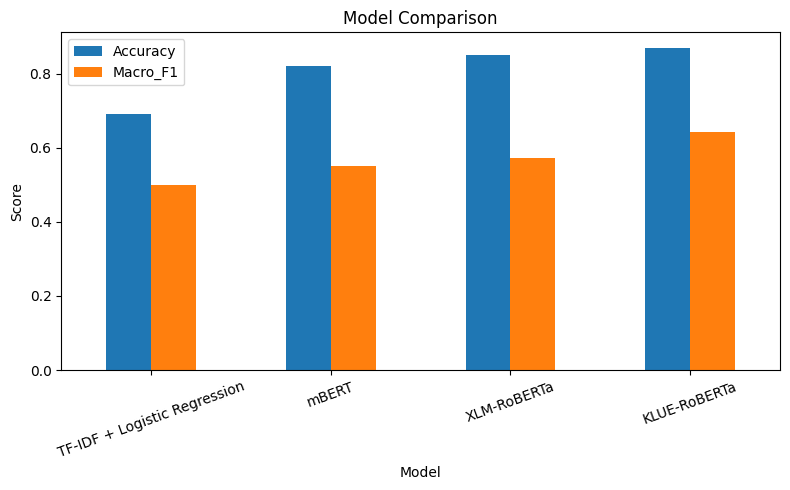

In [4]:
results_summary.plot(x="Model", y=["Accuracy", "Macro_F1"], kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

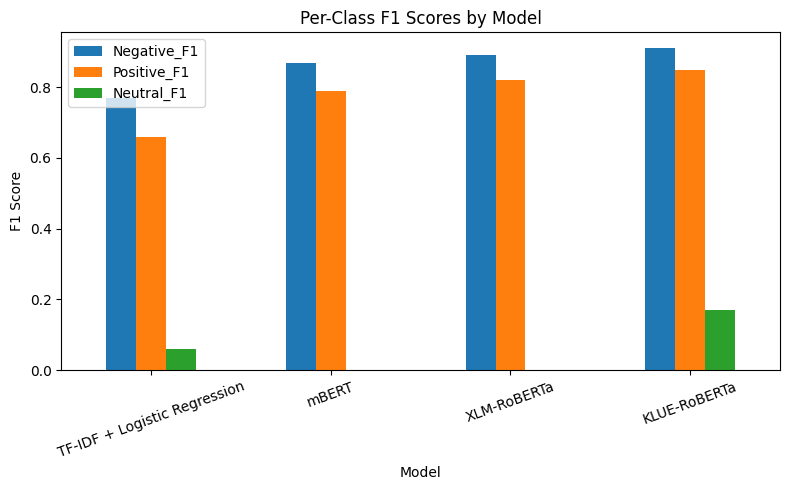

In [3]:
results_summary.plot(
    x="Model",
    y=["Negative_F1", "Positive_F1", "Neutral_F1"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Per-Class F1 Scores by Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# **Appendix. Translation Model**



In [ ]:
trans_model_name = "Helsinki-NLP/opus-mt-ko-en"

trans_tokenizer = AutoTokenizer.from_pretrained(trans_model_name)
trans_model = AutoModelForSeq2SeqLM.from_pretrained(trans_model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
trans_model = trans_model.to(device)
print(device)

cuda


In [ ]:
def translate_texts(texts, batch_size=16, max_input_length=128, max_output_length=128):
    translated_texts = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = trans_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_input_length
        ).to(device)

        outputs = trans_model.generate(
            **inputs,
            max_length=max_output_length
        )

        decoded = trans_tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated_texts.extend(decoded)

        if i % 500 == 0:
            print(f"Translated {i} / {len(texts)}")

    return translated_texts

In [ ]:
sample_translations = translate_texts(df_train["text"].tolist()[:10], batch_size=4)
for i in range(5):
    print("KO:", df_train["text"].iloc[i])
    print("EN:", sample_translations[i])
    print()

Translated 0 / 10
KO: 내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.
EN: I don't know if I liked Tom Hanks... except for the early movies.

KO: 정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요 ㅠ 생각보다 스트레스 심한 직업군이라는 생각입니다.
EN: I think there's a lot of people in the public sector who are dealing with these really mindless, mind-blowing, mind-blowing, mind-blowing, mind-blowing, high-stressed professionals who are suffering from depression and airport disorder.

KO: 새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수함일지도 모르겠습니다. 그걸 가능케 한 사랑에 경의를 표합니다.
EN: The new world and the child-like response of the friendly, perhaps restored, may be pure, not snow, and I salute the love that made it possible.

KO: 미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ
EN: The cyto-living coral reef is an animal, and the micro world is a bird of the ocean.

KO: 네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ
EN: That's right. Flies also fit in 30 frames.

